In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph.message import add_messages
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline, HuggingFaceEmbeddings, HuggingFaceEndpoint
from dotenv import load_dotenv

In [5]:
# Tool
search_tool = DuckDuckGoSearchRun()

@tool
def calculator(a: float, b: float, operation: str) -> float:
    """Performs basic arithmetic operations on two numbers."""
    if operation == "add":
        return a + b
    elif operation == "subtract":
        return a - b
    elif operation == "multiply":
        return a * b
    elif operation == "divide":
        return a / b
    else:
        raise ValueError("Invalid operation")

In [7]:
# Tool Node
tool_node = ToolNode(tools=[search_tool, calculator])

In [14]:
# State
class ModelState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] # add message reducer append new messages to the list by merge strategy

In [10]:
# LLM
load_dotenv()
hf_llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=120,
    temperature=0.7,
)
llm = ChatHuggingFace(llm=hf_llm)

In [37]:
import re
import uuid
def _parse_args(arg_str: str) -> dict:
    args = {}
    for part in arg_str.split(","):
        k, v = part.split("=", 1)
        k, v = k.strip(), v.strip()

        # basic coercion
        if v.replace(".", "", 1).isdigit():
            v = float(v) if "." in v else int(v)
        args[k] = v
    return args

def llm_node(state: ModelState) -> ModelState:
    """LLM Node that generates a response based on the conversation history."""
    
    # bind_tools() is not supported by current LLM, so prompt is used to know about tools and how to use them
    prompt = """
    You are a helpful assistant. If messages include ToolMessage object, you can use the conversation to reply to user query
    else you can use the following tools to answer user queries:
    1. search(query: str) -> str: A tool that allows you to search the web for information.
    2. calculator(a: float, b: float, operation: str) -> float: A tool that allows you to perform basic arithmetic operations (add, subtract, multiply, divide) on two numbers.
    If you use a tool, make sure to provide the necessary arguments in the form of tool call, use the following format:
    [TOOL_NAME](arg1=value1, arg2=value2, ...)
    If you don't need to use a tool, you can directly answer the question based on the conversation history.
    """
    messages = state["messages"] + [prompt]
    response = llm.invoke(messages).content
    text = response.content if hasattr(response, "content") else str(response)

    # Manually adding tool calls in the response for demonstration purposes
    tool_call_regex = r"\[(\w+)\]\((.*?)\)"
    matches = re.findall(tool_call_regex, text)
    if matches:
        tool_calls = []
        for tool_name, raw_args in matches:
            tool_calls.append({
                "id": f"call_{uuid.uuid4().hex[:8]}",
                "type": "tool_call",
                "name": tool_name,
                "args": _parse_args(raw_args),
            })

        clean_text = re.sub(tool_call_regex, "", text).strip() or "Calling tool..."
        ai_msg = AIMessage(content=clean_text, tool_calls=tool_calls)
    else:
        ai_msg = AIMessage(content=text)
    
    return {"messages": [ai_msg]}

In [38]:
# Graph
graph = StateGraph(ModelState)
graph.add_node("LLM", llm_node)
graph.add_node("tools", tool_node)

# Edges
graph.add_edge(START, "LLM")
graph.add_conditional_edges("LLM", tools_condition)
graph.add_edge("tools", "LLM")

worflow = graph.compile()

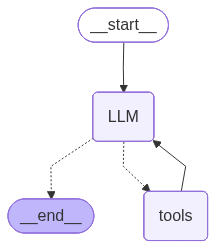

In [39]:
worflow

In [40]:
res = worflow.invoke(input={
    "messages": [
        HumanMessage(content="what is 5 + 3?"),
    ]}
)
res

{'messages': [HumanMessage(content='what is 5 + 3?', additional_kwargs={}, response_metadata={}, id='3e9e1973-42f1-4f70-9731-b261ac985753'),
  AIMessage(content='To calculate 5 + 3, I can use the calculator tool.', additional_kwargs={}, response_metadata={}, id='6bebd8ab-bbd6-4979-874e-f1458ef41c4a', tool_calls=[{'name': 'calculator', 'args': {'a': 5, 'b': 3, 'operation': 'add'}, 'id': 'call_be3b077d', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='8.0', name='calculator', id='e75362d9-35f1-4f27-8eff-b768e10a641e', tool_call_id='call_be3b077d'),
  AIMessage(content="I can use the provided tools to answer your queries. I'll make sure to format my responses according to the guidelines.\n\nTo answer your previous question:\n\n5 + 3 = 8.0\n\nIf you have any more questions, feel free to ask!", additional_kwargs={}, response_metadata={}, id='1bcc86ea-1f37-4cdf-8372-34dd2f52bcf3', tool_calls=[], invalid_tool_calls=[])]}